# Cross Validation

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

In [14]:
df = pd.read_csv(
    "../dataset/processed/feature_engineered_house_prices.csv"
)

In [15]:
df.shape

(2997, 12)

In [16]:
features = [
    "BEDS",
    "BATH",
    "PROPERTYSQFT",
    "TYPE",
    "STATE",
    "LOCALITY"
]

X = df[features]
y = df["PRICE"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [19]:
categorical_features = [
    "TYPE",
    "STATE",
    "LOCALITY"
]

numerical_features = [
    "BEDS",
    "BATH",
    "PROPERTYSQFT"
]

In [20]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=5
            )
        )
    ]
)

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
        (
            "numerical",
            numerical_transformer,
            numerical_features
        )
    ]
)

In [21]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                random_state=42,
                n_jobs=-1,
                objective="reg:squarederror"
            )
        )
    ]
)

In [ ]:
# 5-fold cross-validation

from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
cv_scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R²:", cv_scores.mean())
print("Std R²:", cv_scores.std())

# original test result may not generalize well.

Cross-validation R² scores:
Fold 1: 0.8623
Fold 2: 0.8658
Fold 3: 0.8883
Fold 4: 0.8203
Fold 5: 0.8808

Mean R²: 0.8634891052404823
Std R²: 0.02362299329769942


### Hyperparameter Tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV

In [25]:
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

In [26]:
param_grid = {
    "model__n_estimators": [
        200,
        300,
        500,
        700
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "model__max_depth": [
        3,
        4,
        5,
        6,
        8
    ],

    "model__min_child_weight": [
        1,
        3,
        5
    ],

    "model__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

In [27]:
# Tutning pipeline
tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb)
    ]
)

In [29]:
# Run randamized search
random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [30]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,n_iter,30
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [31]:
# Find best parameters
print("Best Parameters:")

print(
    random_search.best_params_
)

Best Parameters:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}


In [32]:
print(
    "Best CV R²:",
    random_search.best_score_
)

Best CV R²: 0.8667625109353102


In [33]:
best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(
    X_test
)

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [36]:
tuned_mae = mean_absolute_error(
    y_test,
    y_pred_tuned
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

tuned_r2 = r2_score(
    y_test,
    y_pred_tuned
)

In [37]:
# get MAE, RMSE AND R2

print("Tuned XGBoost Results")
print("----------------------")

print(f"MAE  : {tuned_mae:,.2f}")
print(f"RMSE : {tuned_rmse:,.2f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned XGBoost Results
----------------------
MAE  : 16,928,736.36
RMSE : 27,864,528.77
R²   : 0.8691


In [39]:
# Create baseline XGBoost model
baseline_xgb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                random_state=42,
                n_jobs=-1,
                objective="reg:squarederror"
            )
        )
    ]
)

# Train baseline model
baseline_xgb.fit(X_train, y_train)

# Predict
baseline_predictions = baseline_xgb.predict(X_test)

In [40]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline XGBoost")
print("----------------")
print(f"MAE  : {baseline_mae:,.2f}")
print(f"RMSE : {baseline_rmse:,.2f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline XGBoost
----------------
MAE  : 16,161,846.86
RMSE : 28,580,705.55
R²   : 0.8623


In [41]:
best_xgb = random_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)

In [42]:
tuned_mae = mean_absolute_error(
    y_test,
    y_pred_tuned
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned
    )
)

tuned_r2 = r2_score(
    y_test,
    y_pred_tuned
)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Tuned XGBoost"
    ],
    "MAE": [
        baseline_mae,
        tuned_mae
    ],
    "RMSE": [
        baseline_rmse,
        tuned_rmse
    ],
    "R2": [
        baseline_r2,
        tuned_r2
    ]
})

comparison


,Model,MAE,RMSE,R2
0,Baseline XGBoost,1.616185e+07,2.858071e+07,0.862283
1,Tuned XGBoost,1.692874e+07,2.786453e+07,0.869098


In [45]:
# check for overfitting again
train_pred_tuned = best_xgb.predict(X_train)

train_r2 = r2_score(
    y_train,
    train_pred_tuned
)

test_r2 = r2_score(
    y_test,
    y_pred_tuned
)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

# week overfitting. Good for the model

Training R²: 0.9242025844459845
Testing R² : 0.8690984959596917


In [46]:
comparison.to_csv(
    "../dataset/processed/xgboost_tuning_results.csv",
    index=False
)

# Feature Importance

In [47]:
xgb_model = best_xgb.named_steps["model"]

In [48]:
preprocessor_fitted = best_xgb.named_steps["preprocessor"]

In [49]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [50]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
9,categorical__LOCALITY_Colombo 7,0.160430
43,numerical__PROPERTYSQFT,0.108640
41,numerical__BEDS,0.060037
4,categorical__LOCALITY_Awissawella,0.054345
42,numerical__BATH,0.044843
29,categorical__LOCALITY_Mount Lavinia,0.044686
18,categorical__LOCALITY_Kohuwala,0.036693
36,categorical__LOCALITY_Pitakotte,0.034033
30,categorical__LOCALITY_Nawala,0.033599
31,categorical__LOCALITY_Nugegoda,0.032385


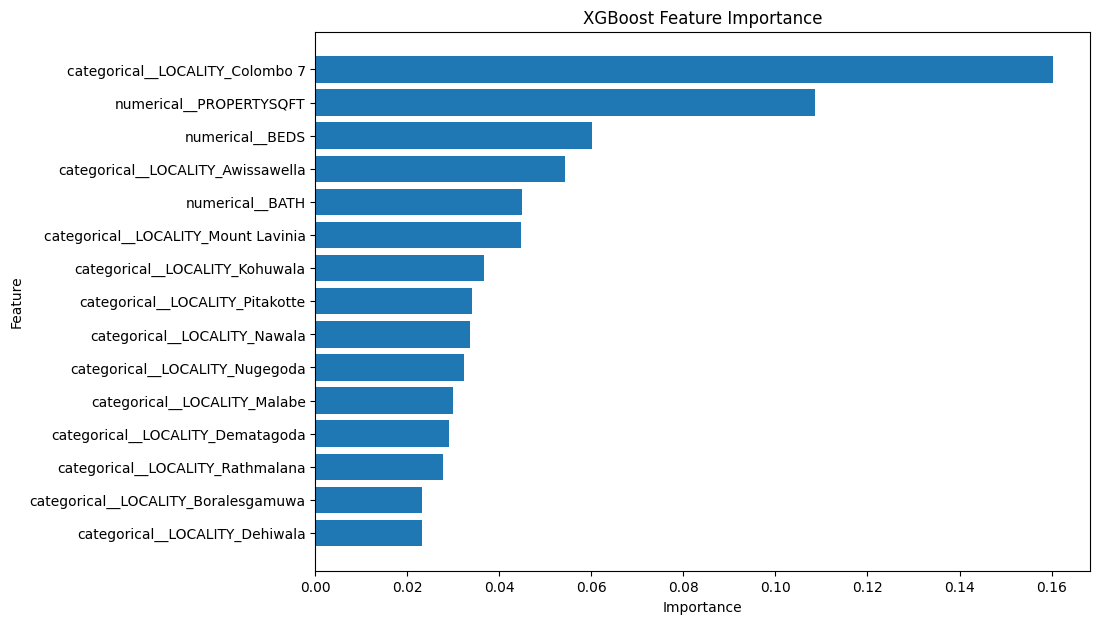

In [51]:
# Visualize feature importance

import matplotlib.pyplot as plt
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [52]:
import json

best_params = random_search.best_params_

with open(
    "../dataset/processed/best_xgb_params.json",
    "w"
) as f:
    json.dump(best_params, f, indent=4)

print("Best parameters saved.")

Best parameters saved.
